In [1]:
import os
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

if False:
    more_basepath = "/user/turishcheva/more_data_like_sensorium_2022"
    for file in [
        "static20457-5-9-94c6ff995dac583098847cfecd43e7b6",
        "static20622-2-14-94c6ff995dac583098847cfecd43e7b6",
        "static20892-10-10-94c6ff995dac583098847cfecd43e7b6",
        "static22223-2-15-94c6ff995dac583098847cfecd43e7b6",
        "static22564-2-12-94c6ff995dac583098847cfecd43e7b6",
        "static22620-4-15-94c6ff995dac583098847cfecd43e7b6",
        "static23555-5-12-94c6ff995dac583098847cfecd43e7b6",
    ]:
        filenames.append(os.path.join(more_basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
def remap_state_dict(state_dict):
    renamed = {}
    for k, v in state_dict.items():
        new_k = k.replace("mask_weights", "spatial_w").replace("mask_bias", "spatial_b")
        if new_k.endswith("spatial_w") or new_k.endswith("spatial_b"):
            if v.dim() == 4 and v.shape[1] == 1:
                v = v.squeeze(1)
        renamed[new_k] = v
    return renamed

In [2]:
gauss_paths = [
    '../training/runs/gaussian_seed0/model_weights.pth',
    '../training/runs/gaussian_seed42/model_weights.pth',
    '../training/runs/gaussian_seed123/model_weights.pth',
]
fact_paths = [
    '../training/runs/factorized_padding_seed0',
    '../training/runs/factorized_padding_seed42',
    '../training/runs/factorized_padding_seed123',
]
reg_paths = [
    '../training/runs/factorized_smooth1e4_seed0',
    '../training/runs/factorized_smooth1e4_seed42',
    '../training/runs/factorized_smooth1e4_seed123',
]
per_n_paths = [
    '../training/runs/factorized_per_neuron_seed0',
    '../training/runs/factorized_per_neuron_seed42',
    '../training/runs/factorized_per_neuron_seed123',
]
reg_per_n_paths = [
    '../training/runs/factorized_smooth1e4_per_neuron_seed0',
    '../training/runs/factorized_smooth1e4_per_neuron_seed42',
    '../training/runs/factorized_smooth1e4_per_neuron_seed123',
]

# gauss_models = []
# for path in gauss_paths:
#     model = load_model_from_config(path, dataloaders, device)
#     gauss_models.append(model)

fact_models = []
for path in fact_paths:
    model = load_model_from_config(path, dataloaders, device)
    fact_models.append(model)

reg_models = []
for path in reg_paths:
    model = load_model_from_config(path, dataloaders, device)
    reg_models.append(model)

per_n_models = []
for path in per_n_paths:
    model = load_model_from_config(path, dataloaders, device)
    per_n_models.append(model)

reg_per_n_models = []
for path in reg_per_n_paths:
    model = load_model_from_config(path, dataloaders, device)
    reg_per_n_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [42]:
from sensorium.utility.scores import get_correlations

for model in fact_models:
    for key in data_keys:
        model.readout[key].temperature = 1.0
    print(get_correlations(model, dataloaders['validation'], device=device, per_neuron=False))

0.4084217
0.4070221
0.40654978


In [4]:
gauss_readouts = []
for model in gauss_models:
    r = torch.cat([model.readout[key].features.detach().squeeze().T for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    gauss_readouts.append(r)

gauss_curve, k_range = get_knn_curve(gauss_readouts)

In [3]:
fact_readouts = []
for model in fact_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    fact_readouts.append(r)

fact_curve, k_range = get_knn_curve(fact_readouts)

In [4]:
reg_readouts = []
for model in reg_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    reg_readouts.append(r)

reg_curve, k_range = get_knn_curve(reg_readouts)

In [5]:
per_n_readouts = []
for model in per_n_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    per_n_readouts.append(r)

per_n_curve, k_range = get_knn_curve(per_n_readouts)

In [6]:
reg_per_n_readouts = []
for model in reg_per_n_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    reg_per_n_readouts.append(r)

reg_per_n_curve, k_range = get_knn_curve(reg_per_n_readouts)

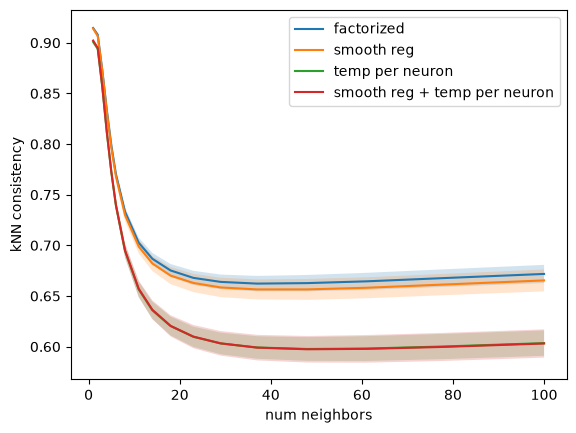

In [7]:
m, s = fact_curve[0], fact_curve[1]
plt.plot(k_range, m, label='factorized')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

m, s = reg_curve[0], reg_curve[1]
plt.plot(k_range, m, label='smooth reg')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

m, s = per_n_curve[0], per_n_curve[1]
plt.plot(k_range, m, label='temp per neuron')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

m, s = reg_per_n_curve[0], reg_per_n_curve[1]
plt.plot(k_range, m, label='smooth reg + temp per neuron')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend()
plt.show()

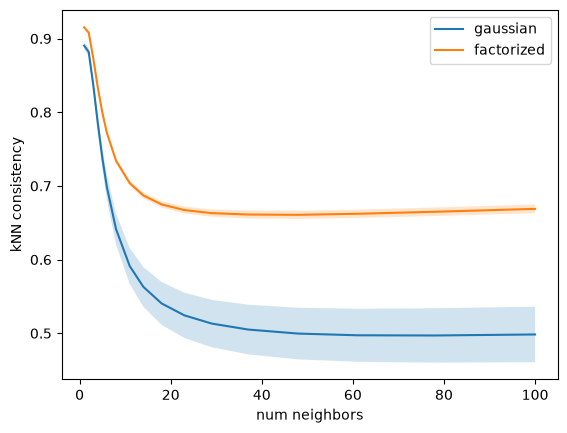

In [7]:
m, s = gauss_curve[0], gauss_curve[1]
plt.plot(k_range, m, label='gaussian')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

m, s = fact_curve[0], fact_curve[1]
plt.plot(k_range, m, label='factorized')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend()
plt.show()

# receptive fields

In [10]:
h, w = 28, 56
gauss_grids = []
for model in gauss_models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grids.append(grid)

    gauss_grids.append(grids)

In [16]:
for model in fact_models:
    for key in data_keys:
        model.readout[key].temperature = 1.0

In [11]:
fact_grids = []
for model in fact_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    fact_grids.append(grids)

In [11]:
half_temp_grids = []
for model in fact_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    half_temp_grids.append(grids)

In [94]:
reg_grids = []
for model in reg_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    reg_grids.append(grids)

In [95]:
per_n_grids = []
for model in per_n_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    per_n_grids.append(grids)

In [ ]:
reg_per_n_grids = []
for model in reg_per_n_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    reg_per_n_grids.append(grids)

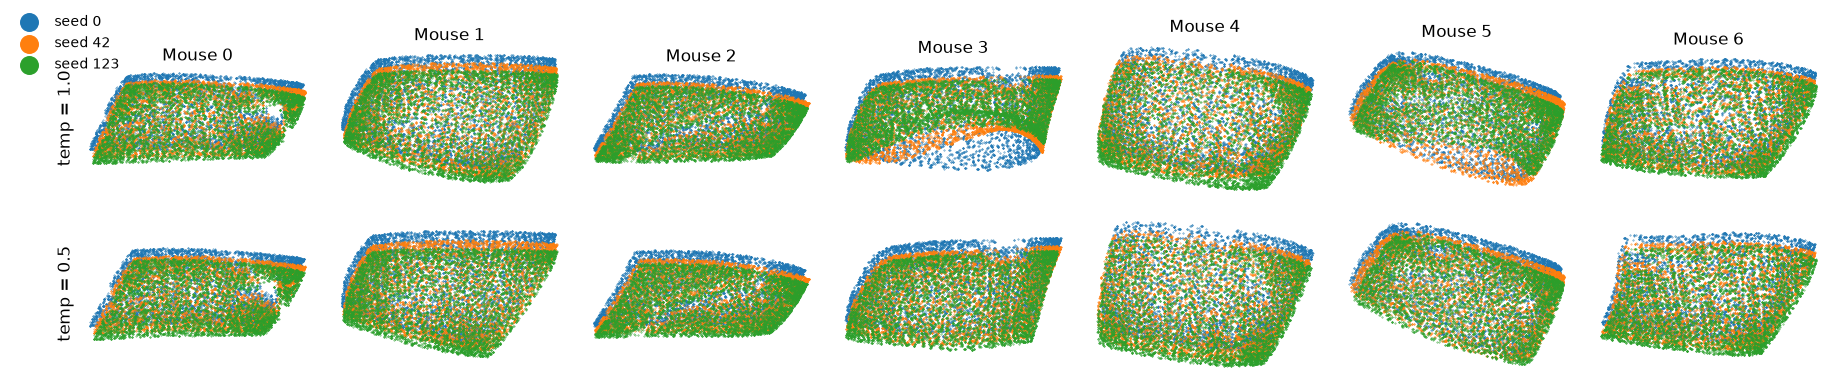

In [12]:
import matplotlib.pyplot as plt

model_seeds = [0, 42, 123]
model_types = {
    # "Gaussian": gauss_grids,
    "temp = 1.0": fact_grids,
    # "Smooth reg": reg_grids,
    "temp = 0.5": half_temp_grids,
    # "Smooth reg + Per neuron temp": reg_per_n_grids,
}

# num_mice = len(gauss_grids[0])
num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, grids) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

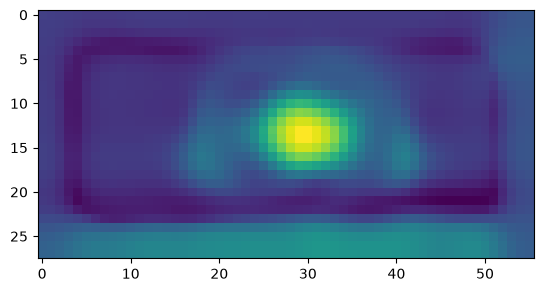

In [6]:
ro = fact_models[2].readout[data_keys[3]]
spatial_w = ro.spatial_w.detach().cpu()
spatial_b = ro.spatial_b.detach().cpu()
spatial = ro.spatial.detach().cpu()
plt.imshow(spatial_b[0])

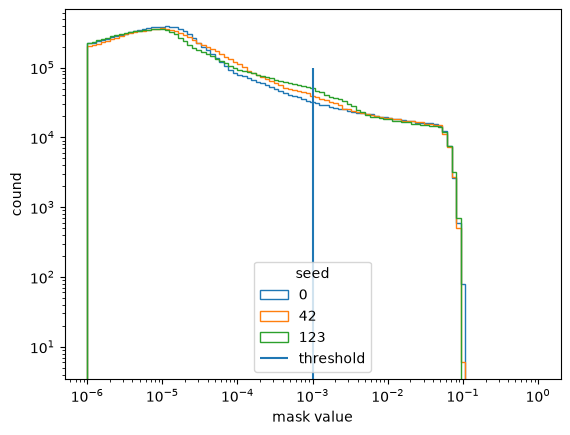

In [8]:
spatials = [model.readout[data_keys[3]].spatial.detach().cpu() for model in fact_models]
# bins = torch.linspace(0.0, 0.12, steps=100)
bins = torch.logspace(-6, 0, steps=100)
for i, spatial in enumerate(spatials):
    plt.hist(spatial.detach().cpu().flatten(), bins=bins, histtype='step', label=[0, 42, 123][i])
plt.vlines(0.001, ymin=0, ymax=1e5, label='threshold')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('mask value')
plt.ylabel('cound')
plt.legend(title='seed')
plt.show()

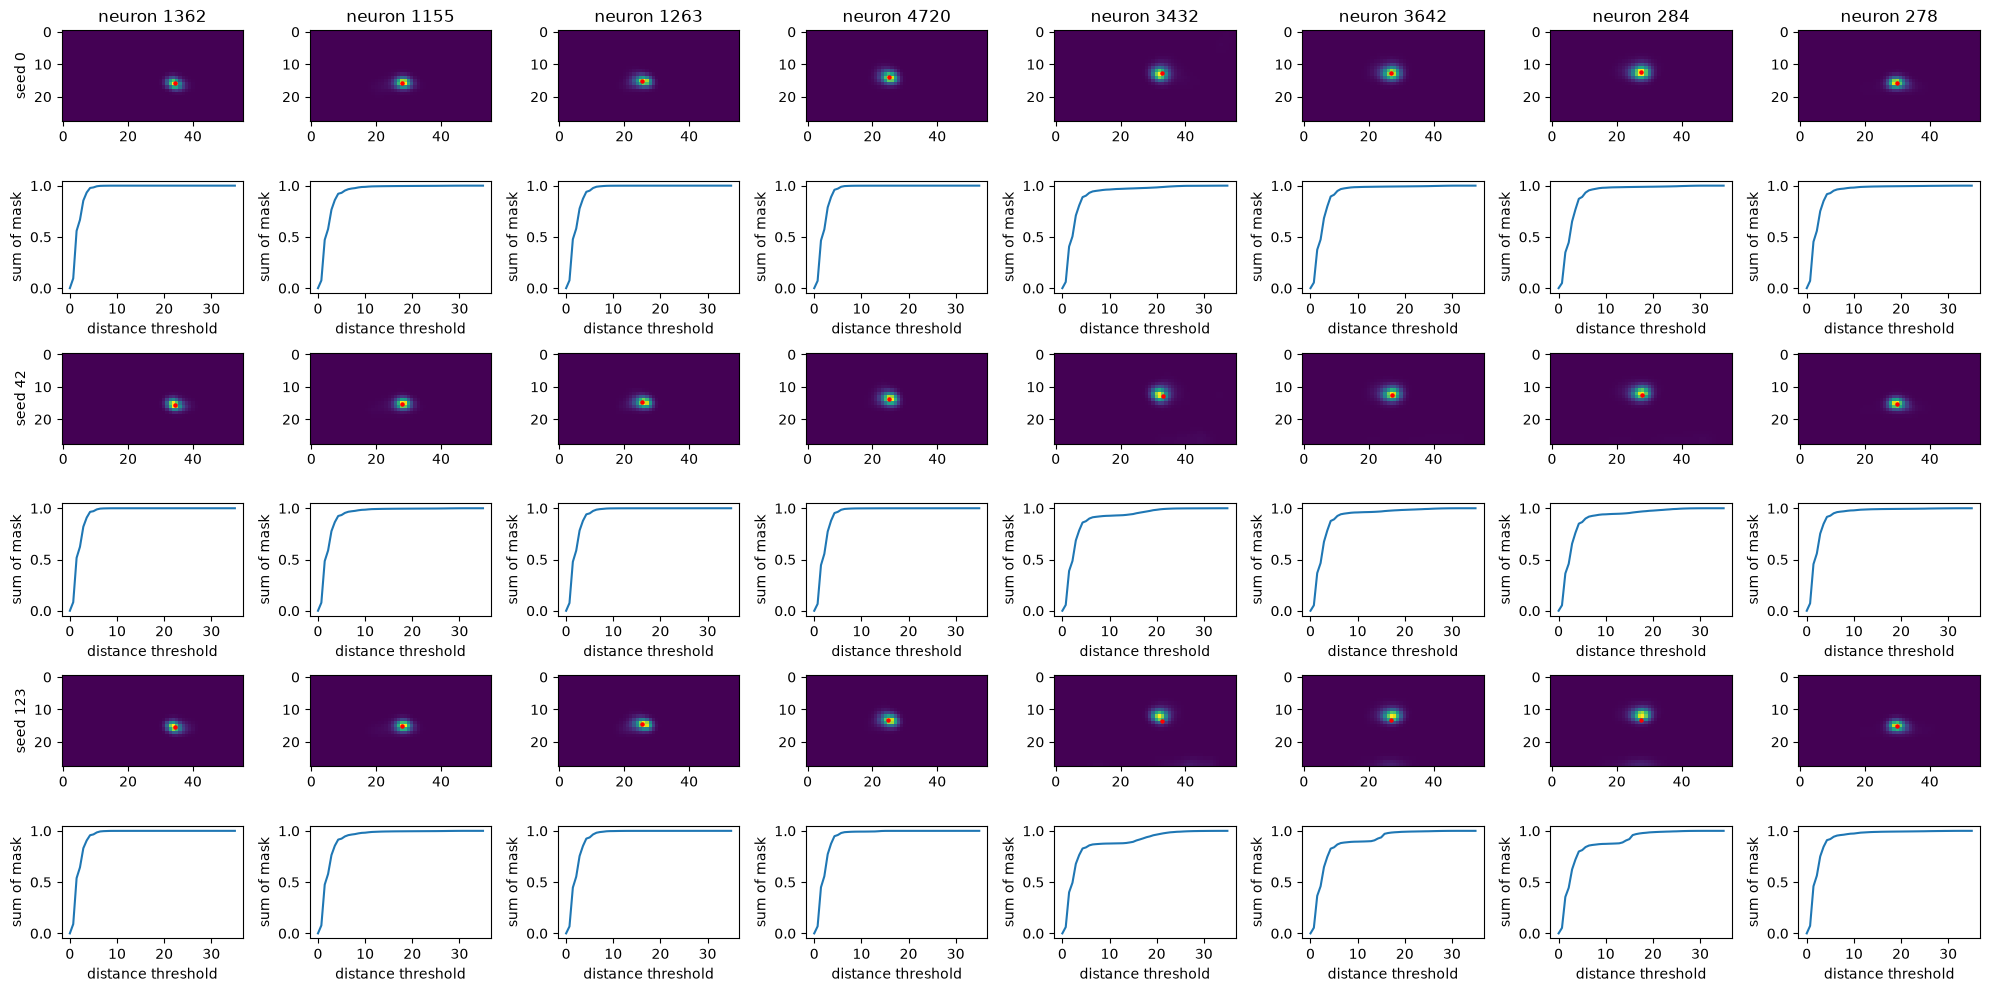

In [89]:
binarized = [spatial > 0.001 for spatial in spatials]

n_neurons = 8
idcs = torch.randperm(5000)
fig, axs = plt.subplots(6, n_neurons, figsize=(20, 10))

for i in range(3):
    for j in range(n_neurons):
        ax = axs[i * 2][j]
        spatial = spatials[i][idcs[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')

        if i == 0:
            ax.set_title(f'neuron {idcs[j]}')
        if j == 0:
            ax.set_ylabel(f'seed {[0, 42, 123][i]}')
        
        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()

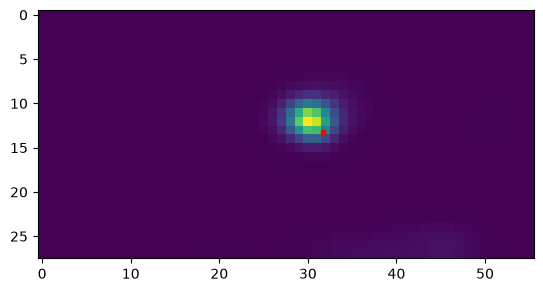

In [39]:
spatial = spatials[1][193]

h, w = spatial.shape
y = spatial.sum(dim=1)  # h
x = spatial.sum(dim=0)  # w

y_pos = torch.arange(h)
x_pos = torch.arange(w)

y_avg = (y_pos * y).sum()
x_avg = (x_pos * x).sum()

y_max = y.argmax()
x_max = x.argmax()

plt.imshow(spatial)
plt.scatter(x_avg, y_avg, s=10, color='red')

In [59]:
y_dist = (y_pos - y_max).pow(2)
x_dist = (x_pos - x_max).pow(2)

yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

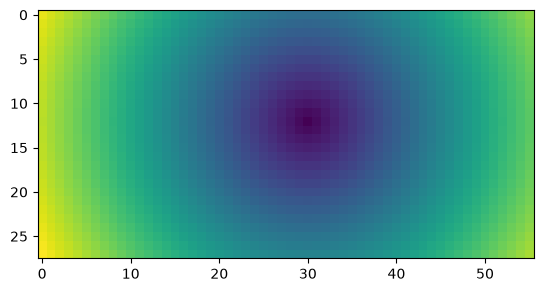

In [60]:
plt.imshow(dists)

In [77]:
thresholds = torch.linspace(0, 35, steps=50)
volumes = []
for t in thresholds:
    vol = spatial[dists < t].sum()
    volumes.append(vol)

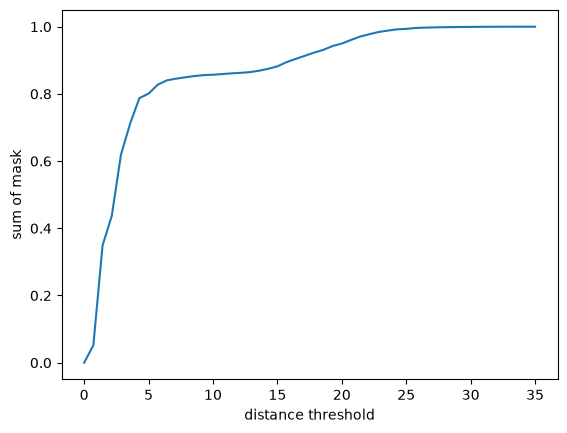

In [80]:
plt.plot(thresholds, volumes)
plt.xlabel('distance threshold')
plt.ylabel('sum of mask')
plt.show()

In [183]:
for type_name, grids in model_types.items():
    grids = [torch.cat(g) for g in grids]
    avgs = []
    print(type_name)
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        d = (grids[i] - grids[j]).pow(2).sum(1).sqrt()
        avg = d.mean()
        avgs.append(avg)
        print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
    print()

temp = 1.0
between seeds: 0, 42: 0.41840440034866333 pixels
between seeds: 0, 123: 0.6559152603149414 pixels
between seeds: 42, 123: 0.3000560998916626 pixels

temp = 0.5
between seeds: 0, 42: 0.43436864018440247 pixels
between seeds: 0, 123: 0.7024853229522705 pixels
between seeds: 42, 123: 0.27982595562934875 pixels



# shifters

In [82]:
gauss_shifts = []
for model in gauss_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    gauss_shifts.append(shifts)

In [101]:
fact_shifts = []
for model in fact_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = -(shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = -(shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    fact_shifts.append(shifts)

In [102]:
per_n_shifts = []
for model in per_n_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = -(shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = -(shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    per_n_shifts.append(shifts)

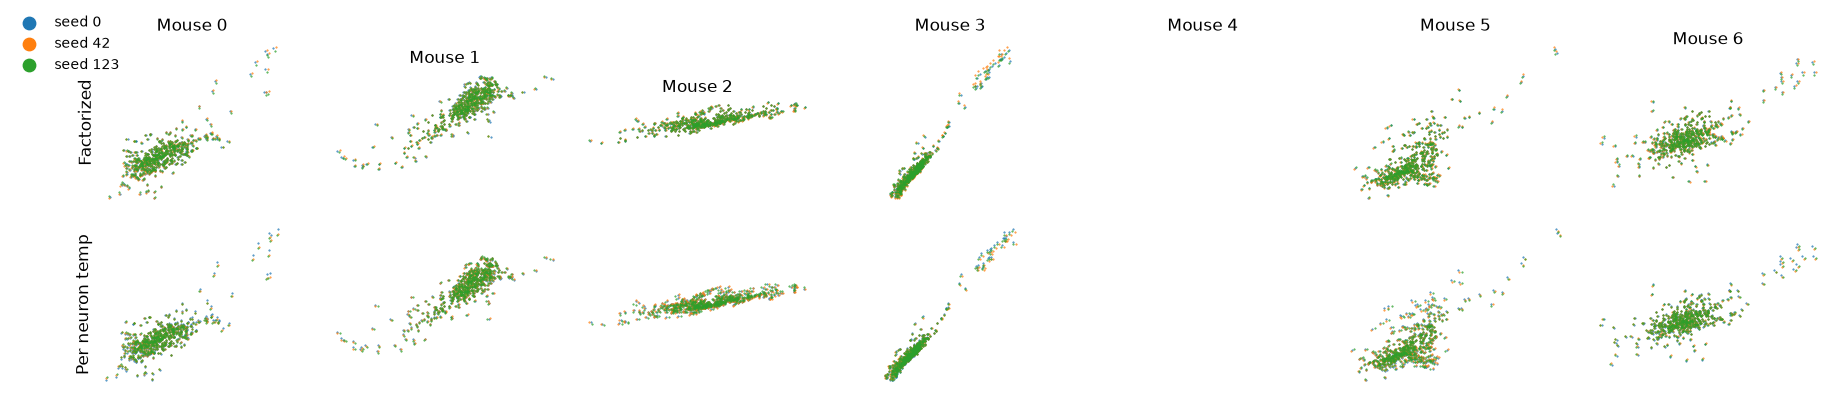

In [104]:
import matplotlib.pyplot as plt

model_seeds = [0, 42, 123]
model_types = {
    # "Gaussian": gauss_shifts,
    "Factorized": fact_shifts,
    "Per neuron temp": per_n_shifts,
}

# num_mice = len(gauss_grids[0])
num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, shifts) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            shift = shifts[model_idx][mouse_idx]
            if shift is not None:
                ax.scatter(
                    shift[:, 0], shift[:, 1],
                    alpha=1, s=0.2,
                    label=f"seed {model_seeds[model_idx]}",
                )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=20,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [105]:
for type_name, shifts in model_types.items():
    shifts = [torch.cat(g) for g in shifts]
    avgs = []
    print(type_name)
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        d = (shifts[i] - shifts[j]).pow(2).sum(1).sqrt()
        avg = d.mean()
        avgs.append(avg)
        print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
    print()

Factorized
between seeds: 0, 42: 0.020084096118807793 pixels
between seeds: 0, 123: 0.01637749932706356 pixels
between seeds: 42, 123: 0.02191217429935932 pixels

Per neuron temp
between seeds: 0, 42: 0.022350231185555458 pixels
between seeds: 0, 123: 0.030611513182520866 pixels
between seeds: 42, 123: 0.025450922548770905 pixels

